<a href="https://colab.research.google.com/github/samiulislam22/Machine_Learning-and-Neural_Networks_projects/blob/main/credit_card_churn_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
!kaggle --version
!kaggle auth --help

Kaggle CLI 2.2.4
usage: kaggle auth [-h] {login,print-access-token,revoke} ...

options:
  -h, --help            show this help message and exit

commands:
  {login,print-access-token,revoke}
    login               Authenticate to Kaggle
    print-access-token  Print an access token for the active account
    revoke              Revoke the active account's refresh token


In [24]:
!kaggle auth login

You are already logged-in to Kaggle as [mdsamiulislam24].
Please use the --force flag to override.


In [25]:
!kaggle datasets download -d rjmanoj/credit-card-customer-churn-prediction

Dataset URL: https://www.kaggle.com/datasets/rjmanoj/credit-card-customer-churn-prediction
License(s): unknown
credit-card-customer-churn-prediction.zip: Skipping, found more recently modified local copy (use --force to force download)


In [26]:
!unzip -q credit-card-customer-churn-prediction.zip -d churn_data

replace churn_data/Churn_Modelling.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [27]:
!ls churn_data

Churn_Modelling.csv


In [28]:
import pandas as pd

In [29]:
df = pd.read_csv('churn_data/Churn_Modelling.csv')

In [30]:
df.shape

(10000, 14)

In [31]:
df.head(-1)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9994,9995,15719294,Wood,800,France,Female,29,2,0.00,2,0,0,167773.55,0
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [33]:
df.duplicated().sum() #this is to check if there is any duplicate rows

np.int64(0)

In [34]:
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)

In [41]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [41]:
# to get the numerical valuoes only of the dataset removing strings
df = pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True)

In [44]:
# scaling the values
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Exited'])
y = df['Exited']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=1)

In [45]:
X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,True,False,True


In [46]:
y

,Exited
0,1
1,0
2,1
3,0
4,0
...,...
9995,0
9996,0
9997,1
9998,1


In [47]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [48]:
X_train_scaled

array([[-0.23082038, -0.94449979, -0.70174202, ...,  1.71490137,
        -0.57273139,  0.91509065],
       [-0.25150912, -0.94449979, -0.35520275, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [-0.3963303 ,  0.77498705,  0.33787579, ...,  1.71490137,
        -0.57273139, -1.09278791],
       ...,
       [ 0.22433188,  0.58393295,  1.3774936 , ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 0.13123255,  0.01077067,  1.03095433, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 1.1656695 ,  0.29735181,  0.33787579, ...,  1.71490137,
        -0.57273139,  0.91509065]])

In [49]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [71]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=X_train_scaled.shape[1])) # Use input_dim from X_train_scaled
model.add(Dense(8,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [72]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 10)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 8)              │            88 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 217 (868.00 B)

 Trainable params: 217 (868.00 B)

 Non-trainable params: 0 (0.00 B)

In [73]:
model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [88]:
history = model.fit(X_train_scaled, y_train, epochs=100, validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8672 - loss: 0.3206 - val_accuracy: 0.8506 - val_loss: 0.3336
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8687 - loss: 0.3208 - val_accuracy: 0.8506 - val_loss: 0.3328
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8678 - loss: 0.3205 - val_accuracy: 0.8506 - val_loss: 0.3355
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8670 - loss: 0.3214 - val_accuracy: 0.8525 - val_loss: 0.3333
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8677 - loss: 0.3203 - val_accuracy: 0.8506 - val_loss: 0.3343
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8681 - loss: 0.3206 - val_accuracy: 0.8525 - val_loss: 0.3352
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8689 - loss: 0.3209 - val_accuracy: 0.8537 - val_loss: 0.3325
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8687 - loss: 0.3205 - val_accu

In [92]:
model.layers[0].get_weights()

[array([[ 0.40902928,  0.16028178,  0.02442853,  0.11784496,  0.13141122,
          0.14498876, -0.08606283, -0.00519566, -0.18580708, -0.12754196],
        [ 0.44511005, -0.21500197, -0.49606404,  0.23995684,  1.6582869 ,
         -0.6028201 ,  0.1037171 ,  0.7298199 ,  0.32378605, -0.27359003],
        [ 0.20838666,  0.25464955, -0.15663037,  0.2611382 ,  0.16365227,
          0.19562435, -0.35726714,  0.3944477 , -0.14555658, -0.3249244 ],
        [ 0.39610147, -1.0645413 , -0.11357037,  0.10807791, -0.30207387,
          0.08083614, -0.5594839 , -0.37616727, -0.5210595 ,  0.2479765 ],
        [-0.99716914, -0.25309324, -0.20670699,  1.5807452 ,  0.06942914,
         -0.13812304, -0.504668  ,  0.29800126, -1.2359449 , -0.5899537 ],
        [-0.3485604 , -0.02875246,  0.01784117,  0.07511876, -0.01156704,
         -0.09769535, -0.19754706,  0.42865166,  0.10415341,  0.26806253],
        [-0.4891915 , -0.7749399 , -0.462209  , -0.64865947,  0.14416619,
         -0.5454351 ,  1.2480482

In [93]:
y_log = model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [94]:
import numpy as np
y_pred = np.where(y_log>0.5,1,0)

In [95]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.864

In [96]:
import matplotlib.pyplot as plt

In [98]:
history.history

{'accuracy': [0.8671875,
  0.8687499761581421,
  0.8678125143051147,
  0.8670312762260437,
  0.8676562309265137,
  0.8681250214576721,
  0.8689062595367432,
  0.8687499761581421,
  0.8682812452316284,
  0.8693749904632568,
  0.8673437237739563,
  0.8671875,
  0.866406261920929,
  0.8675000071525574,
  0.8684375286102295,
  0.866406261920929,
  0.8690624833106995,
  0.8685937523841858,
  0.8681250214576721,
  0.8685937523841858,
  0.8668749928474426,
  0.8706250190734863,
  0.8684375286102295,
  0.8706250190734863,
  0.8707812428474426,
  0.8695312738418579,
  0.8685937523841858,
  0.8700000047683716,
  0.8675000071525574,
  0.8704687356948853,
  0.8673437237739563,
  0.8687499761581421,
  0.867968738079071,
  0.8678125143051147,
  0.8704687356948853,
  0.8681250214576721,
  0.8682812452316284,
  0.8678125143051147,
  0.8696874976158142,
  0.8689062595367432,
  0.8685937523841858,
  0.8693749904632568,
  0.8693749904632568,
  0.8696874976158142,
  0.8704687356948853,
  0.869374990463256

(0.3, 0.5)

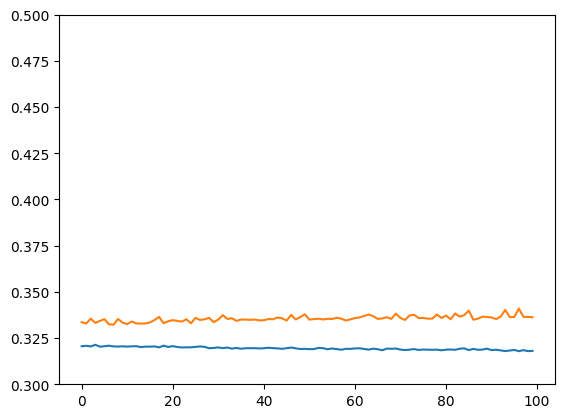

In [113]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.ylim(0.3,0.5)

(0.7, 0.9)

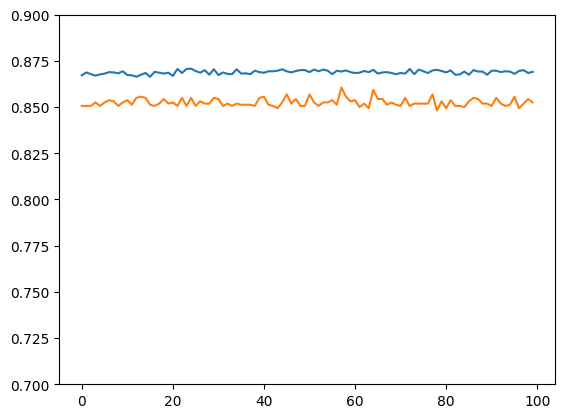

In [111]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.ylim(0.7,0.9)